<a href="https://colab.research.google.com/github/nuuuuurinn/Assessing-Racial-Disparities-in-Maternity-Care-with-Machine-Learning/blob/main/ParentPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

# LOAD DATA
# Mortality data (2018-2022)
df_deaths = pd.read_excel('Multiple Cause of Death, 2018-2024, Single Race.xlsx')

# Natality data (2018-2022)
df_births = pd.read_excel('Natality, 2016-2024 expanded.xlsx')

# 2017 Births (for Age-Standardization weights)
df_2017 = pd.read_excel('Natality, 2017.xlsx')

# PREPARE 2017 STANDARDIZATION WEIGHTS
# Focus strictly on the relevant childbearing age range (15-54)
age_codes = ['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54']

weights_df = df_2017[df_2017['Age of Mother 9 Code'].isin(age_codes)].copy()
total_births_2017 = weights_df['Births'].sum()

# Calculate the percentage (weight) of births that happened in each age group in 2017
weights_df['weight'] = weights_df['Births'] / total_births_2017
weights = weights_df.set_index('Age of Mother 9 Code')['weight'].to_dict()


# DEFINE ANNUAL ASR CALCULATION
def calculate_annual_asr(target_year):
    """
    Calculates the Age-Standardized Rate for a single specific year.
    """
    # Filter both datasets for the specific year we are looking at
    d_year = df_deaths[df_deaths['Year'] == target_year]
    b_year = df_births[df_births['Year'] == target_year]

    annual_asr = 0
    total_deaths = d_year['Deaths'].sum()

    # Loop through each age group to calculate the standardized rate
    for age in age_codes:
        # Get deaths and births for this specific age group in this specific year
        d = d_year[d_year['Five-Year Age Groups Code'] == age]['Deaths'].sum()
        b = b_year[b_year['Age of Mother 9 Code'] == age]['Births'].sum()

        # Get the standard weight for this age group (calculated from 2017 data)
        w = weights.get(age, 0)

        if b > 0:
            crude_rate = (d / b) * 100000
            annual_asr += (crude_rate * w)

    return annual_asr, int(total_deaths)


# 4. LOOP THROUGH YEARS AND PRINT RESULTS
print("--- ANNUAL AGE-STANDARDIZED MORTALITY RATES (2018-2022) ---")

for year in range(2018, 2023):  # range(2018, 2023) covers 2018 through 2022
    asr, total_deaths = calculate_annual_asr(year)
    print(f"{year}: ASR of {asr:.1f} deaths per 100,000 live births (Total Deaths: {total_deaths})")

--- ANNUAL AGE-STANDARDIZED MORTALITY RATES (2018-2022) ---
2018: ASR of 23.2 deaths per 100,000 live births (Total Deaths: 888)
2019: ASR of 26.4 deaths per 100,000 live births (Total Deaths: 1008)
2020: ASR of 31.5 deaths per 100,000 live births (Total Deaths: 1167)
2021: ASR of 41.0 deaths per 100,000 live births (Total Deaths: 1561)
2022: ASR of 30.0 deaths per 100,000 live births (Total Deaths: 1159)


The slightly lower numbers in your Python output compared to the published table are primarily due to data suppression and dataset access levels.

Here is what is missing:

Privacy Suppression (<10 Rule): The public CDC WONDER database automatically suppresses (hides) death counts of less than 10 within any specific demographic or geographic group to protect privacy. When Pandas reads these suppressed cells, it treats them as 0.

Public vs. Restricted Data: The authors of the study almost certainly used the CDC's restricted-use, line-level mortality files. This allows them to sum every single death, including the 1–9 count groups that are completely hidden from the public datasets you downloaded.

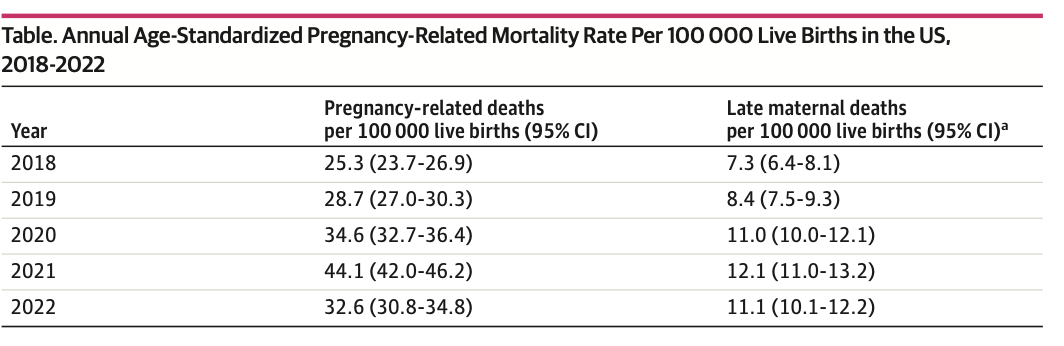